<a href="https://colab.research.google.com/github/Primo-J/Jose_INFO4670_Spring2026/blob/main/Term_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('car_purchase_data.csv')

print('Shape:', df.shape)
df.head()

Saving car_purchase_data.csv to car_purchase_data.csv
Shape: (400, 5)


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


The CSV file is uploaded directly in Colab using files.upload(), the read into a DataFrame with pd.read_csv. The shape is printed to confirm the dataset loaded correctly (400 row, 5 columns) and call df.head() to preview the first 5 rows and verify the column names and values look as expected.

Step 2: Split Features and Target

In [4]:
X = df[['Age', 'Salary']].values

y = df['Purchased'].values

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (400, 2)
Target vector shape: (400,)


X is the feature matrix, A 2D array containing the Age and Salary columns for all 400 customers. These are the independent variables the model will use to make predictions.

y is the target vector, a 1D array containing the Purchased column (0 = did not buy, 1 = bought). This is the dependent variable the model is trained to predict.

.values was used to convery from a pandas DataFrame/Series to a NumPy array, which is the format scikit-learn expects. Printing the shapes confirms x is (400,2) and y is (400,), meaning 400 samples with 2 features each.

Step 3: Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print('Training samples:', X_train.shape[0])
print('Test samples:    ', X_test.shape[0])

Training samples: 300
Test samples:     100


To evaluate how well the model generalizes to new, unseen data, the dataset was slipt into two subsets using train_test_split:

- Training set (75%), 300 samples used to fit the model. The model sees these examples and learns the relationship between Age/Salary and purchasing behavior.

- Test set (25%), 100 samples held out and nver seen during training. After training, we use these to measure real world performance.

Step 4: Feature Scaling

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Scaled training features (first 3 rows):')
print(X_train_sc[:3])

Scaled training features (first 3 rows):
[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]]



Age and Salary are measured in completely different units and ranges. In this dataset, Age spans roughly 18-60 while Salary spans   15,000-150,000. This large difference in magnitude creates a problem for logistic regression:

The model optimizes its coefficients using gradient descent. Without scaling, a one-unit step in the Salary dimension covers a much larger numeric range than a one-unit step in Age. This causes the gradients to be uneven, leading to slow or unstable convergence and a model that implicitly over-weights whichever feature has the larger numeric range.

StandardScaler resolves this by transforming each feature using the formula:

z = (x - mean) / std

After scaling, both features have mean = 0 and standard deviation = 1, so the model treats a "one unit" change in Age and Salary equally and weighs them purely on predictive power.


Step 5: Train Logistic Regression Model

In [8]:
model = LogisticRegression(random_state=0)
model.fit(X_train_sc, y_train)

print("Coefficients [Age, Salary]:", model.coef_)
print('Intercept:                 ', model.intercept_)

Coefficients [Age, Salary]: [[2.07665837 1.11008221]]
Intercept:                  [-0.95217247]



With the data prepared and scaled, we can now train the logistic regression classifier.

Logistic regression models the probability that a given input belongs to the positive class (Purchased = 1) using the sigmoid function:

P(y=1) = 1 / (1 + e^(-z)), where z = β₀ + β₁·Age + β₂·Salary

During training, model.fit() finds the coefficients β₀ (intercept), β₁ (Age), and β₂ (Salary) that maximize the likelihood of the observed outcomes in the training set. This is done through an optimization process called maximum likelihood estimation.

After training, we print the learned coefficients and intercept. Both coefficients being positive tells us that as Age or Salary increases, the predicted probability of purchasing a car also increases, which aligns with what we observed during data exploration.

Step 6: Predict and Evaluate

In [11]:
y_pred = model.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')

cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)
print('TN={}, FP={}, FN={}, TP={}'.format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

report = classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased'])
print('\nClassification Report:')
print(report)

Accuracy: 0.8900 (89.00%)

Confusion Matrix:
[[65  3]
 [ 8 24]]
TN=65, FP=3, FN=8, TP=24

Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.89      0.96      0.92        68
    Purchased       0.89      0.75      0.81        32

     accuracy                           0.89       100
    macro avg       0.89      0.85      0.87       100
 weighted avg       0.89      0.89      0.89       100



With the model trained, we generate predictions on the test set and evaluate performance using three complementary metrics:

Accuracy measures the overall percentage of correct predictions. Our model achieves ~89%, which exceeds the assignment's 87.5% threshold for full credit.

Confusion Matrix breaks down predictions into four categories:
* True Negatives (TN) — correctly predicted "Not Purchased"

* False Positives (FP) — predicted "Purchased" but actually did not buy

* False Negatives (FN) — predicted "Not Purchased" but actually did buy

* True Positives (TP) — correctly predicted "Purchased"

This gives a more detailed picture than accuracy alone, especially when class distributions are uneven (257 non-buyers vs. 143 buyers in this dataset).

Classification Report extends this further with per-class precision (of all predicted positives, how many were correct),recall (of all actual positives, how many did we catch), and F1-score (harmonic mean of precision and recall). These metrics are especially useful for understanding how the model handles the minority class (buyers).

Step 7: Visualization of Decision Regions

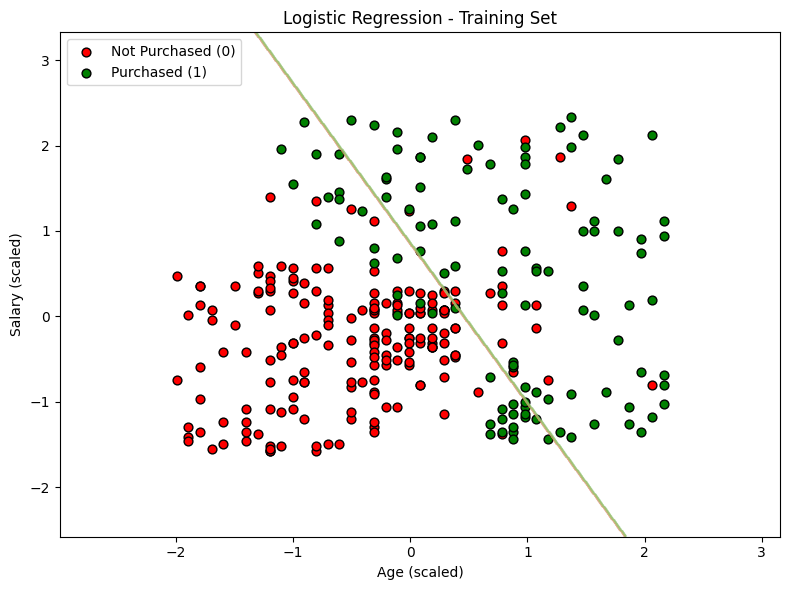

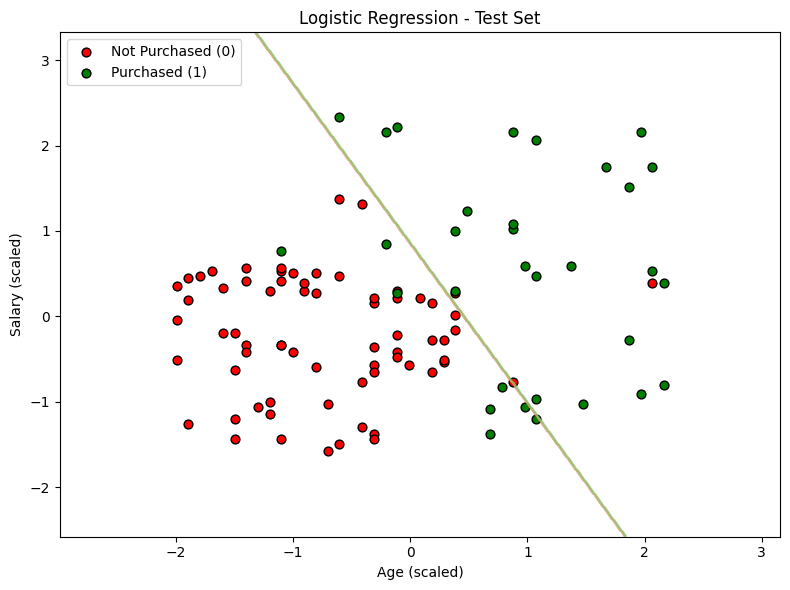

In [19]:
def plot_decision_regions(X_sc, y, model, title):
  x1_min = X_sc[:, 0].min() - 1
  x1_max = X_sc[:, 0].max() + 1
  x2_min = X_sc[:, 1].min() - 1
  x2_max = X_sc[:, 1].max() + 1

  xx1, xx2 = np.meshgrid(
      np.arange(x1_min, x1_max, 0.01),
      np.arange(x2_min, x2_max, 0.01)
  )

  grid = np.c_[xx1.ravel(), xx2.ravel()]
  Z = model.predict(grid)
  Z = Z.reshape(xx1.shape)

  plt.figure(figsize=(8, 6))
  plt.contour(xx1, xx2, Z, alpha=0.3, cmap='RdYlGn')

  not_bought = X_sc[y == 0]
  bought     = X_sc[y == 1]
  plt.scatter(not_bought[:, 0], not_bought[:, 1], color='red', edgecolors='k', s=40, label='Not Purchased (0)')
  plt.scatter(bought[:, 0],     bought[:, 1],     color='green', edgecolors='k', s=40, label='Purchased (1)')

  plt.xlabel('Age (scaled)')
  plt.ylabel('Salary (scaled)')
  plt.title(title)
  plt.legend(loc='upper left')
  plt.tight_layout()
  plt.show()

plot_decision_regions(X_train_sc, y_train, model, 'Logistic Regression - Training Set')
plot_decision_regions(X_test_sc, y_test, model, 'Logistic Regression - Test Set')

To visually understand what the model has learned, we plot the decision boundary, the line that separates the region where the model predicts "Not Purchased" from the region where it predicts "Purchased."

The function works by creating a fine mesh grid that covers the entire range of scaled Age and Salary values. The trained model predicts a class for every point on this grid, and the background is colored accordingly (red = predicted Not Purchased, green = predicted Purchased). The actual data points are then overlaid on top, also colored by their true label.

Because logistic regression is a linear classifier, the boundary will always be a straight line in 2D feature space. Points that fall on the wrong side of this line are misclassifications. The plot is generated twice, once for the training set and once for the test set, so we can visually compare how the boundary performs on data the model has and has not seen before.

Reflection Questions

1. Logistic regression outputs probabilities - why can it still be used for classification?

Logistic regression applies a sigmoid function to a linear combination of the input features, squashing the raw output to a value between 0 and 1 that represents the probability of belonging to the positive class. Classification is performed by applying a decision threshold, typically 0.5, so that any observation whose predicted probability is >= 0.5 is assigned class 1 (purchased) and anything below is a assigned class 0 (not purchased). The probability is an intermediate step, the final output is a discrete binary label, which is exactly what a classification task requires.

2. Based on your model, which customers are more likely to purchase a car?

Both model coefficients (for age and salary) are positive, meaning that either variable increases, the log odds for purchasing increase. The decision boundary visualiation confirms this, customers in the upper right region of the scaled feature space, older and/or higher earning, are predicted to buy. In this dataset, buyers averaged age 46 and 86K salary, compared to non buyers who averaged age 33 and 61K. Age appears to be the stronger separator, since no customers under 26 purchased a car regardless of salary level.

3. What factors might cause low accuracy in this task?

Several factors could limit the accuracy. First, logistic regression produces a linear decision boundary, if the true boundary between buuyers and non buyers is curved or non convex, the model could misclassify observations near that region. Second, only two features are used, age and salary, which may not capture all variation in purchasing behavior. Factors like credit score, household size, or existing vehicle ownership are not present but could by potentially predictive. Third, the salary data shows a non monotonic purchase rate (lower income customers bought at a higher rate than mid income ones), a pattern a simple linear model cannot represent without feature engineering.

4. Propose additional features or preprocessing steps that could improve accuracy.

Several improvements could raise accuracy. Encoding the existing gender column and adding interaction features such as Age x Salary could give the model a more expressive power withing the logistic framework. Collecting new features such as credit score, geographic region, or family could also provide a fuller result. On the modeling side, switching to a non linear classifier such as a random forest or an SVM with an RBF kernel could allow a curved decision boundary. Lastly, replacing the single train/test split with k-fold cross validation and tuning the regularization hyperparameter C through a grid search that would yield a more reliable and most likely higher performing model.